# Simulasi Shor's Algorithm
## Perbandingan Multi-N: Exact QFT vs Approximate QFT
**Reproduksi: Sun, Zhang, Franchetti — CMU HPEC 2023**

---

Notebook ini membandingkan performa **Exact QFT vs Approximate QFT**
untuk beberapa bilangan komposit N sekaligus.

Setiap N dijalankan dua kali:
1. Dengan **Exact QFT** → `QFT(n_count, inverse=True)` bawaan Qiskit
2. Dengan **Approximate QFT** → implementasi manual **Listing 1 jurnal**

Hasil dikumpulkan dalam satu tabel perbandingan dan divisualisasikan bersama.

> **Platform:** BRIN HPC Trembesi — CPU Only

***1. Import Library***

In [2]:
import numpy as np
import math
import random
import time
from fractions import Fraction

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator

***2. Pilih Daftar N yang Akan Dibandingkan***

In [3]:
# ── Daftar N sesuai partition Trembesi ───────────────────────────
# Partition interactive (2 jam)  → gunakan N_LIST_INTERACTIVE
# Partition short       (1 hari) → gunakan N_LIST_SHORT

N_LIST_INTERACTIVE = [15, 21, 35]          # aman di 2 jam
N_LIST_SHORT       = [35, 77, 111 ]  # aman di 1 hari

# ← Ganti sesuai partition yang digunakan
N_LIST = N_LIST_SHORT

SHOTS  = 4096   # jumlah shots per simulasi

print(f"Daftar N yang akan diuji : {N_LIST}")
print(f"Shots per simulasi       : {SHOTS}")
print(f"Total simulasi           : {len(N_LIST) * 2} (masing-masing Exact + Approx)")
print()

# Estimasi waktu total (kasar)
def estimasi(N, shots):
    n       = math.ceil(math.log2(N))
    n_count = 2 * n
    return (2 ** (n_count + n)) / 1e7 * shots * 2

total_est = sum(estimasi(N, SHOTS) for N in N_LIST)
print(f"Estimasi total waktu : ~{total_est:.0f}s (~{total_est/60:.1f} menit)")
print()
print(f"{'N':>6} {'n_count':>8} {'n_work':>7} {'Est (s)':>9}")
print("-" * 35)
for N in N_LIST:
    n       = math.ceil(math.log2(N))
    n_count = 2 * n
    print(f"{N:>6} {n_count:>8} {n:>7} {estimasi(N, SHOTS):>9.1f}")

Daftar N yang akan diuji : [35, 77, 111]
Shots per simulasi       : 4096
Total simulasi           : 6 (masing-masing Exact + Approx)

Estimasi total waktu : ~3651s (~60.8 menit)

     N  n_count  n_work   Est (s)
-----------------------------------
    35       12       6     214.7
    77       14       7    1718.0
   111       14       7    1718.0


***3. Definisi Fungsi***

In [4]:
# ── Fungsi Perkalian Modular ──────────────────────────────────────
def modular_multiplication(a, N, n):
    size   = 2 ** n
    perm   = np.zeros(size, dtype=int)
    for y in range(size):
        perm[y] = (a * y) % N if y < N else y
    U_perm = np.zeros((size, size), dtype=complex)
    for y in range(size):
        U_perm[perm[y], y] = 1.0
    return UnitaryGate(U_perm)


# ── Approximate QFT — Listing 1 Jurnal ───────────────────────────
def approximate_qft(circuit, register, n, kmax):
    """
    Implementasi langsung dari Listing 1 jurnal.
    Gate CP(π/2^k) DILEWATI jika (i-j) > kmax.
    """
    i = n - 1
    while i >= 0:
        circuit.h(register[i])
        j = i - 1
        while j >= 0 and (i - j) <= kmax:
            angle = np.pi / (2 ** (i - j))
            circuit.cp(angle, register[i], register[j])
            j -= 1
        i -= 1
    for k in range(n // 2):
        circuit.swap(register[k], register[n - 1 - k])


# ── Bangun Sirkuit ────────────────────────────────────────────────
def build_circuit(N, a, use_approx=False):
    """
    Bangun sirkuit Shor untuk N dan a.
    use_approx=False → Exact QFT (bawaan Qiskit)
    use_approx=True  → Approximate QFT (Listing 1 jurnal)
    """
    n       = math.ceil(math.log2(N))
    n_count = 2 * n
    kmax    = math.floor(math.log2(n_count))

    qc    = QuantumCircuit(n_count + n, n_count)
    phase = list(range(n_count))
    work  = list(range(n_count, n_count + n))

    for q in phase:
        qc.h(q)
    qc.barrier()

    qc.x(work[0])
    qc.barrier()

    for q in range(n_count):
        exp  = pow(a, 2**q, N)
        U    = modular_multiplication(exp, N, n)
        ctrl = U.control()
        qc.append(ctrl, [phase[q]] + work)
    qc.barrier()

    if use_approx:
        approximate_qft(qc, phase, n_count, kmax)
    else:
        qc.append(QFT(n_count, inverse=True), phase)
    qc.barrier()

    qc.measure(phase, range(n_count))
    return qc, n_count, kmax


# ── Temukan Faktor ────────────────────────────────────────────────
def find_factors(counts, n_count, N, a):
    for state, _ in sorted(counts.items(), key=lambda x: -x[1])[:15]:
        state_clean = state.replace(' ', '')[:n_count]
        if state_clean == '0' * n_count:
            continue
        dec  = int(state_clean, 2)
        frac = Fraction(dec / (2**n_count)).limit_denominator(N)
        r    = frac.denominator
        if r == 0 or r % 2 != 0:
            continue
        p = math.gcd(pow(a, r//2) - 1, N)
        q = math.gcd(pow(a, r//2) + 1, N)
        if p not in (1, N) and N % p == 0:
            return r, p, N // p
        if q not in (1, N) and N % q == 0:
            return r, q, N // q
    return None, None, None


# ── Hitung Correctness ────────────────────────────────────────────
def hitung_correctness(counts, n_count, N, a, shots):
    success = 0
    Q       = 2 ** n_count
    for state, cnt in counts.items():
        dec = int(state.replace(' ', '')[:n_count], 2)
        if dec == 0:
            continue
        frac = Fraction(dec / Q).limit_denominator(N)
        r    = frac.denominator
        if r == 0 or r % 2 != 0:
            continue
        p = math.gcd(pow(a, r//2) - 1, N)
        q = math.gcd(pow(a, r//2) + 1, N)
        if p not in (1, N) or q not in (1, N):
            success += cnt
    return round(success / shots * 100, 2)


print("✅ Semua fungsi siap.")

✅ Semua fungsi siap.


***4. Jalankan Simulasi untuk Semua N***

In [5]:
sim     = AerSimulator()
results = []   # simpan semua hasil di sini

for N in N_LIST:
    n       = math.ceil(math.log2(N))
    n_count = 2 * n

    # Pilih a secara acak yang coprime dengan N
    candidates = [a for a in range(2, N-1) if math.gcd(a, N) == 1]
    a          = random.choice(candidates)

    kmax = math.floor(math.log2(n_count))

    print(f"{'─'*52}")
    print(f"  N={N}, a={a}, n_count={n_count}, kmax={kmax}")
    print(f"{'─'*52}")

    # ── Exact QFT ─────────────────────────────────────────────────
    qc_e, _, _ = build_circuit(N, a, use_approx=False)
    print(f"  [Exact]  depth={qc_e.depth()}", end="  ", flush=True)

    t0           = time.time()
    compiled_e   = transpile(qc_e, sim, optimization_level=3)
    result_e     = sim.run(compiled_e, shots=SHOTS).result()
    t_exact      = time.time() - t0
    counts_e     = result_e.get_counts()

    r_e, p_e, q_e = find_factors(counts_e, n_count, N, a)
    CE             = hitung_correctness(counts_e, n_count, N, a, SHOTS)
    print(f"t={t_exact:.2f}s  C={CE:.1f}%  {'✅ '+str(p_e)+'×'+str(q_e) if p_e else '❌'}")

    # ── Approximate QFT ───────────────────────────────────────────
    qc_a, _, _ = build_circuit(N, a, use_approx=True)
    print(f"  [Approx] depth={qc_a.depth()}", end="  ", flush=True)

    t1           = time.time()
    compiled_a   = transpile(qc_a, sim, optimization_level=3)
    result_a     = sim.run(compiled_a, shots=SHOTS).result()
    t_approx     = time.time() - t1
    counts_a     = result_a.get_counts()

    r_a, p_a, q_a = find_factors(counts_a, n_count, N, a)
    CA             = hitung_correctness(counts_a, n_count, N, a, SHOTS)
    print(f"t={t_approx:.2f}s  C={CA:.1f}%  {'✅ '+str(p_a)+'×'+str(q_a) if p_a else '❌'}")

    # Hitung gate CP
    cp_exact  = n_count * (n_count - 1) // 2
    cp_approx = sum(min(kmax, i) for i in range(n_count))
    reduksi   = round((1 - cp_approx / cp_exact) * 100, 1) if cp_exact > 0 else 0
    rel       = round(abs(CE - CA) / CE * 100, 2) if CE > 0 else 0
    speedup   = round(t_exact / t_approx, 2) if t_approx > 0 else 0

    # Simpan hasil
    results.append({
        'N':          N,
        'a':          a,
        'n_count':    n_count,
        'kmax':       kmax,
        'CE':         CE,
        'CA':         CA,
        'rel_diff':   rel,
        'speedup':    speedup,
        'cp_exact':   cp_exact,
        'cp_approx':  cp_approx,
        'reduksi':    reduksi,
        'depth_e':    qc_e.depth(),
        'depth_a':    qc_a.depth(),
        't_exact':    round(t_exact,  3),
        't_approx':   round(t_approx, 3),
        'r_e':        r_e,   'p_e': p_e,   'q_e': q_e,
        'r_a':        r_a,   'p_a': p_a,   'q_a': q_a,
        'counts_e':   counts_e,
        'counts_a':   counts_a,
    })

print()
print("✅ Semua simulasi selesai!")

────────────────────────────────────────────────────
  N=35, a=6, n_count=12, kmax=3
────────────────────────────────────────────────────
  [Exact]  depth=16  

/tmp/ipykernel_1235429/1797018464.py:64: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_count, inverse=True), phase)


t=2.43s  C=50.7%  ✅ 5×7
  [Approx] depth=39  t=2.13s  C=49.4%  ✅ 5×7
────────────────────────────────────────────────────
  N=77, a=59, n_count=14, kmax=3
────────────────────────────────────────────────────
  [Exact]  depth=18  t=31.77s  C=45.5%  ✅ 11×7
  [Approx] depth=45  t=87.51s  C=43.3%  ✅ 11×7
────────────────────────────────────────────────────
  N=111, a=35, n_count=14, kmax=3
────────────────────────────────────────────────────
  [Exact]  depth=18  t=32.26s  C=72.9%  ✅ 3×37
  [Approx] depth=45  t=31.33s  C=70.1%  ✅ 3×37

✅ Semua simulasi selesai!


***5. Tabel Perbandingan — Semua N***

In [6]:
print("=" * 72)
print("  TABEL PERBANDINGAN MULTI-N")
print("  Exact QFT vs Approximate QFT (Listing 1 Jurnal)")
print("=" * 72)
print(f"  {'N':>5} {'a':>4} {'CE%':>6} {'CA%':>6} {'RD%':>6} {'Spdup':>6} "
      f"{'CP-E':>7} {'CP-A':>7} {'Red%':>6} {'t_E(s)':>8} {'t_A(s)':>8}")
print("  " + "-" * 68)

for r in results:
    print(
        f"  {r['N']:>5} {r['a']:>4}"
        f"  {r['CE']:>5.1f}  {r['CA']:>5.1f}  {r['rel_diff']:>5.1f}"
        f"  {r['speedup']:>5.2f}"
        f"  {r['cp_exact']:>6}  {r['cp_approx']:>6}  {r['reduksi']:>5.1f}"
        f"  {r['t_exact']:>7.3f}  {r['t_approx']:>7.3f}"
    )

print("=" * 72)
print()
print("  Keterangan:")
print("  CE%   = Correctness Exact QFT (%)")
print("  CA%   = Correctness Approximate QFT (%)")
print("  RD%   = Relative Difference |CE-CA|/CE × 100%")
print("  Spdup = Speedup = t_exact / t_approx")
print("  CP-E  = Jumlah gate CP Exact")
print("  CP-A  = Jumlah gate CP Approximate")
print("  Red%  = Reduksi gate CP (%)")

print()
print("  Hasil faktor:")
for r in results:
    s_e = f"{r['p_e']}×{r['q_e']}" if r['p_e'] else "tidak ditemukan"
    s_a = f"{r['p_a']}×{r['q_a']}" if r['p_a'] else "tidak ditemukan"
    print(f"  N={r['N']:>4}  Exact: {s_e:<15}  Approx: {s_a}")

  TABEL PERBANDINGAN MULTI-N
  Exact QFT vs Approximate QFT (Listing 1 Jurnal)
      N    a    CE%    CA%    RD%  Spdup    CP-E    CP-A   Red%   t_E(s)   t_A(s)
  --------------------------------------------------------------------
     35    6   50.7   49.4    2.5   1.14      66      30   54.5    2.434    2.133
     77   59   45.5   43.3    5.0   0.36      91      36   60.4   31.771   87.506
    111   35   72.9   70.1    3.9   1.03      91      36   60.4   32.262   31.328

  Keterangan:
  CE%   = Correctness Exact QFT (%)
  CA%   = Correctness Approximate QFT (%)
  RD%   = Relative Difference |CE-CA|/CE × 100%
  Spdup = Speedup = t_exact / t_approx
  CP-E  = Jumlah gate CP Exact
  CP-A  = Jumlah gate CP Approximate
  Red%  = Reduksi gate CP (%)

  Hasil faktor:
  N=  35  Exact: 5×7              Approx: 5×7
  N=  77  Exact: 11×7             Approx: 11×7
  N= 111  Exact: 3×37             Approx: 3×37


***6. Probability Spectrum — Semua N (Fig. 3 Jurnal)***

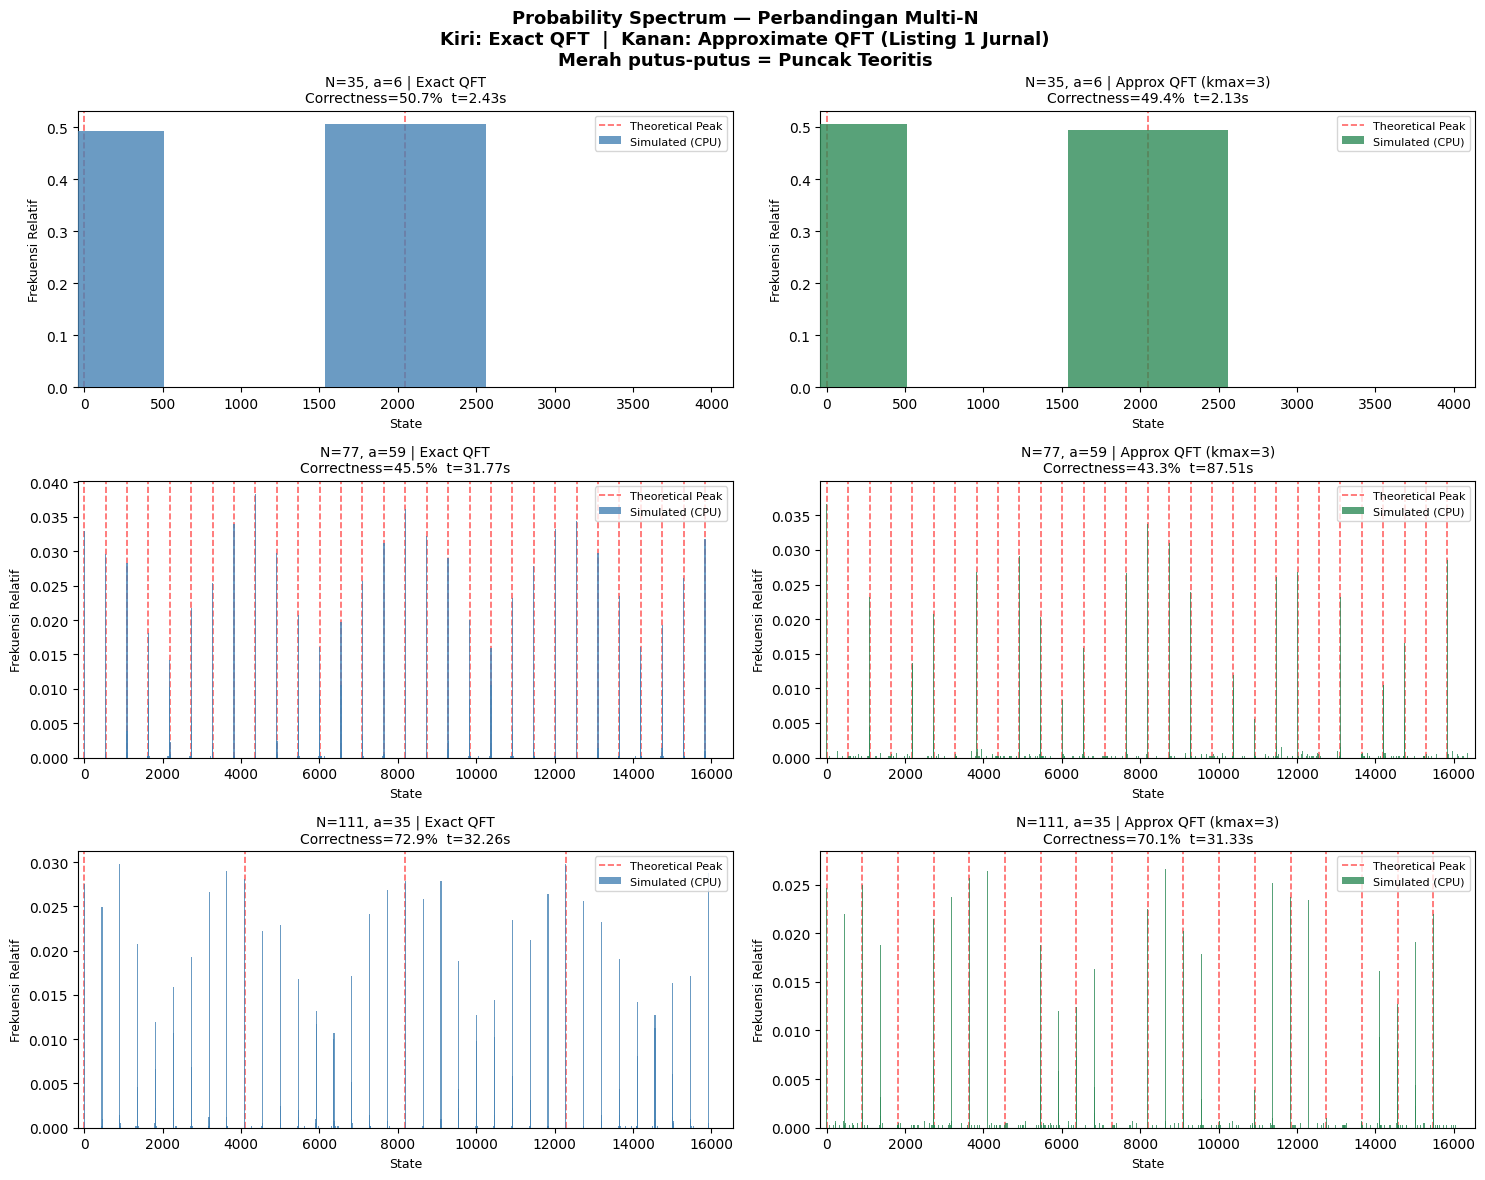

Gambar disimpan: spectrum_multi_N.png


In [7]:
# Plot grid: baris = setiap N, kolom = Exact | Approx
n_rows = len(results)
fig, axes = plt.subplots(n_rows, 2,
                          figsize=(15, 4 * n_rows),
                          squeeze=False)

fig.suptitle(
    "Probability Spectrum — Perbandingan Multi-N\n"
    "Kiri: Exact QFT  |  Kanan: Approximate QFT (Listing 1 Jurnal)\n"
    "Merah putus-putus = Puncak Teoritis",
    fontsize=13, fontweight='bold'
)

for row, r in enumerate(results):
    N       = r['N']
    n_count = r['n_count']
    Q       = 2 ** n_count

    for col, (counts_plot, r_plot, label, color, ce) in enumerate([
        (r['counts_e'], r['r_e'],
         f"Exact QFT", 'steelblue', r['CE']),
        (r['counts_a'], r['r_a'],
         f"Approx QFT (kmax={r['kmax']})", 'seagreen', r['CA']),
    ]):
        ax = axes[row][col]

        # Konversi ke desimal
        dec_counts = {}
        for state, cnt in counts_plot.items():
            dec = int(state.replace(' ', '')[:n_count], 2)
            dec_counts[dec] = dec_counts.get(dec, 0) + cnt

        total  = sum(dec_counts.values())
        x_vals = sorted(dec_counts.keys())
        y_vals = [dec_counts[x] / total for x in x_vals]

        # Puncak teoritis (merah)
        if r_plot:
            theo = [round(k * Q / r_plot) % Q for k in range(r_plot)]
            for i, p in enumerate(theo):
                ax.axvline(p, color='red', linestyle='--',
                           alpha=0.6, linewidth=1.2,
                           label='Theoretical Peak' if i == 0 else '')

        # Bar distribusi
        bar_w = max(Q // max(len(x_vals), 1) // 2, 5)
        ax.bar(x_vals, y_vals, width=bar_w,
               color=color, alpha=0.8, zorder=3,
               label='Simulated (CPU)')

        ax.set_title(
            f"N={N}, a={r['a']} | {label}\n"
            f"Correctness={ce:.1f}%  t={r['t_exact' if col==0 else 't_approx']:.2f}s",
            fontsize=10
        )
        ax.set_xlabel('State', fontsize=9)
        ax.set_ylabel('Frekuensi Relatif', fontsize=9)
        ax.set_xlim(-Q * 0.01, Q * 1.01)
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('spectrum_multi_N.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan: spectrum_multi_N.png")

***7. Grafik Perbandingan Antar N***

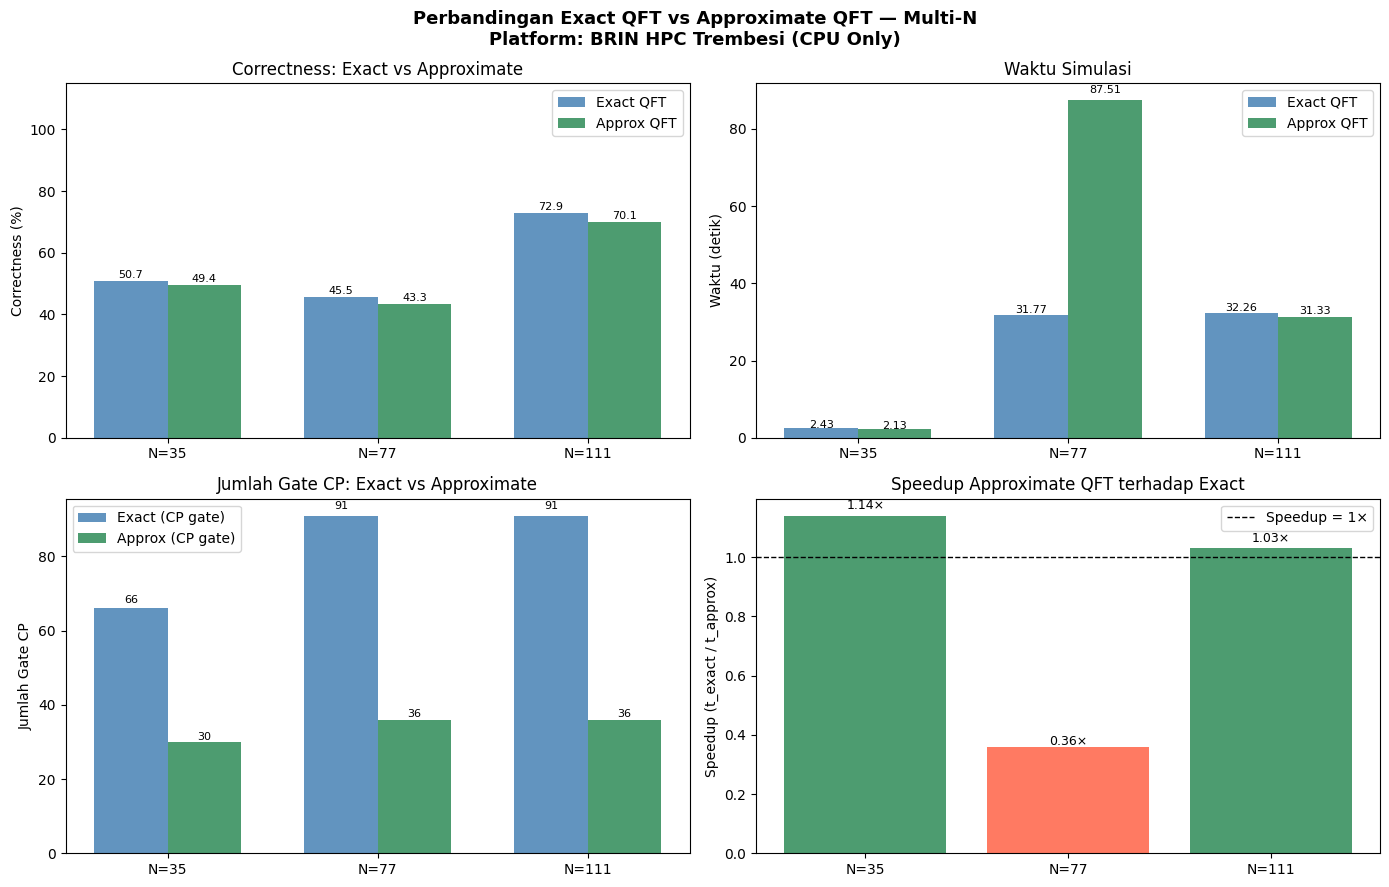

Gambar disimpan: comparison_multi_N.png


In [8]:
labels    = [f"N={r['N']}" for r in results]
x         = np.arange(len(labels))
width     = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Perbandingan Exact QFT vs Approximate QFT — Multi-N\n"
    "Platform: BRIN HPC Trembesi (CPU Only)",
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Correctness ──────────────────────────────────────────
ax = axes[0][0]
ax.bar(x - width/2, [r['CE'] for r in results],
       width, label='Exact QFT', color='steelblue', alpha=0.85)
ax.bar(x + width/2, [r['CA'] for r in results],
       width, label='Approx QFT', color='seagreen', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Correctness (%)')
ax.set_title('Correctness: Exact vs Approximate')
ax.set_ylim(0, 115)
ax.legend()
for i, r in enumerate(results):
    ax.text(i - width/2, r['CE'] + 1, f"{r['CE']:.1f}", ha='center', fontsize=8)
    ax.text(i + width/2, r['CA'] + 1, f"{r['CA']:.1f}", ha='center', fontsize=8)

# ── Plot 2: Waktu Simulasi ───────────────────────────────────────
ax = axes[0][1]
ax.bar(x - width/2, [r['t_exact']  for r in results],
       width, label='Exact QFT', color='steelblue', alpha=0.85)
ax.bar(x + width/2, [r['t_approx'] for r in results],
       width, label='Approx QFT', color='seagreen', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Waktu (detik)')
ax.set_title('Waktu Simulasi')
ax.legend()
for i, r in enumerate(results):
    ax.text(i - width/2, r['t_exact']  * 1.02, f"{r['t_exact']:.2f}",  ha='center', fontsize=8)
    ax.text(i + width/2, r['t_approx'] * 1.02, f"{r['t_approx']:.2f}", ha='center', fontsize=8)

# ── Plot 3: Reduksi Gate CP ──────────────────────────────────────
ax = axes[1][0]
ax.bar(x - width/2, [r['cp_exact']  for r in results],
       width, label='Exact (CP gate)', color='steelblue', alpha=0.85)
ax.bar(x + width/2, [r['cp_approx'] for r in results],
       width, label='Approx (CP gate)', color='seagreen', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Jumlah Gate CP')
ax.set_title('Jumlah Gate CP: Exact vs Approximate')
ax.legend()
for i, r in enumerate(results):
    ax.text(i - width/2, r['cp_exact']  * 1.02, str(r['cp_exact']),  ha='center', fontsize=8)
    ax.text(i + width/2, r['cp_approx'] * 1.02, str(r['cp_approx']), ha='center', fontsize=8)

# ── Plot 4: Speedup ──────────────────────────────────────────────
ax = axes[1][1]
bars = ax.bar(labels, [r['speedup'] for r in results],
              color=['seagreen' if r['speedup'] >= 1 else 'tomato'
                     for r in results], alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Speedup = 1×')
ax.set_ylabel('Speedup (t_exact / t_approx)')
ax.set_title('Speedup Approximate QFT terhadap Exact')
ax.legend()
for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.02,
            f"{r['speedup']:.2f}×", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_multi_N.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan: comparison_multi_N.png")

***8. Relative Difference Correctness per N***

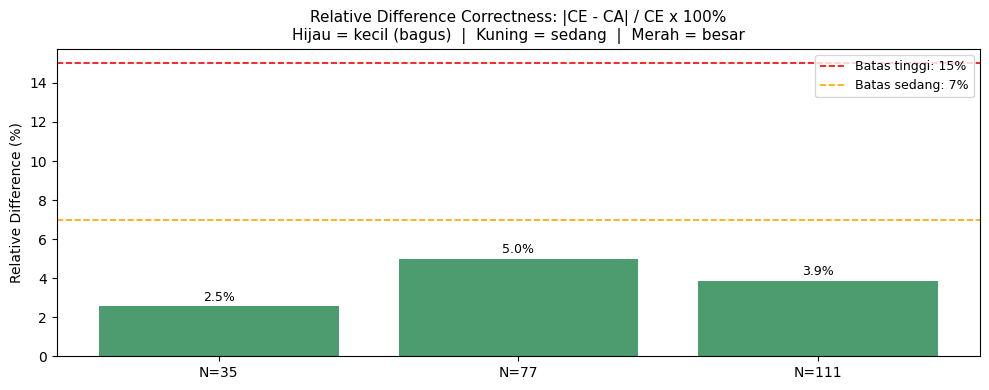

Gambar disimpan: relative_diff_multi_N.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['tomato' if r['rel_diff'] > 15 else 'orange'
          if r['rel_diff'] > 7 else 'seagreen'
          for r in results]

bars = ax.bar(labels, [r['rel_diff'] for r in results],
              color=colors, alpha=0.85)

# Threshold dari jurnal
ax.axhline(15, color='red',    linestyle='--', linewidth=1.2,
           label='Batas tinggi: 15%')
ax.axhline(7,  color='orange', linestyle='--', linewidth=1.2,
           label='Batas sedang: 7%')

ax.set_ylabel('Relative Difference (%)')
ax.set_title(
    'Relative Difference Correctness: |CE - CA| / CE x 100%\n'
    'Hijau = kecil (bagus)  |  Kuning = sedang  |  Merah = besar',
    fontsize=11
)
ax.legend(fontsize=9)

for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{r['rel_diff']:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('relative_diff_multi_N.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan: relative_diff_multi_N.png")

***9. Info Node***

In [10]:
import socket, sys, os
print(f"Hostname   : {socket.gethostname()}")
print(f"Python     : {sys.version.split()[0]}")
print(f"Executable : {sys.executable}")
print(f"CPU cores  : {os.cpu_count()}")

print()
print("File output:")
for f in sorted(os.listdir('.')):
    if f.endswith('.png'):
        print(f"  📊 {f} ({os.path.getsize(f)//1024} KB)")

Hostname   : trembesi91
Python     : 3.10.19
Executable : /mgpfs/home/mkhairiansyah/.conda/envs/env-ml/bin/python
CPU cores  : 128

File output:
  📊 comparison_multi_N.png (141 KB)
  📊 gate_reduction.png (77 KB)
  📊 grover.png (8 KB)
  📊 grover_circuit.png (16 KB)
  📊 grover_hist.png (16 KB)
  📊 performance_analysis.png (125 KB)
  📊 qft_comparison.png (37 KB)
  📊 relative_diff_multi_N.png (50 KB)
  📊 shor_N35_a27.png (114 KB)
  📊 shor_histogram_N111_a98.png (175 KB)
  📊 shor_histogram_N35_a4.png (135 KB)
  📊 shor_periodic_histogram.png (169 KB)
  📊 shor_representatif_N111_a98.png (316 KB)
  📊 shor_representatif_N35_a4.png (212 KB)
  📊 spectrum_N15_a2.png (104 KB)
  📊 spectrum_N35_a2.png (109 KB)
  📊 spectrum_multi_N.png (224 KB)
